In [2]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

In [6]:
wd = 0.642570281124498
wm = 1.0
tau = 100
tlist = np.linspace(0, tau, 200)
N = 12
dlist = np.linspace(0, 1, 11)

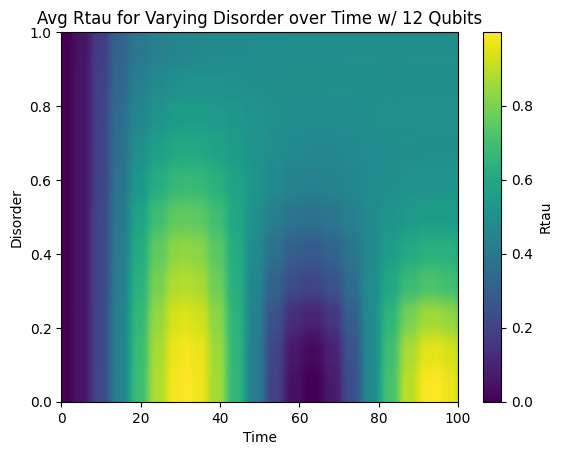

In [7]:
avgRtau_imshow = []
H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
basisLen = len(basisList)

for d in dlist:
    scar_dR = []
    for _ in range(10):
        diag_vals = np.random.uniform(-d, d, basisLen)
        diag_vals -= np.mean(diag_vals)
        diagLocation = list(range(basisLen))
        H_anharm = csr_matrix((diag_vals, (diagLocation, diagLocation)), shape=(basisLen, basisLen))
        H_anharm = qt.Qobj(H_anharm)

        Hscar = H0 + H_anharm
        deigvals, deigstates = Hscar.eigenstates()
        band = deigvals[-1] - deigvals[0]

        args = {"A": 0.1, "omega": wd}
        H = qt.QobjEvo([Hscar, [H1, coeff]], args=args)
        psi_t = qt.sesolve(H, deigstates[0], tlist)

        # eq 2.3
        temp = []
        H00 = psi_t.states[0].dag() * Hscar * psi_t.states[0]
        for states in psi_t.states:
            H0tau = states.dag() * Hscar * states
            Etau = H0tau - H00
            temp.append(Etau.real)
        temp = np.array(temp)
        scar_dR.append(temp / band)
    scar_dR = np.array(scar_dR)
    avgRtau_imshow.append(np.mean(scar_dR, axis=0))

plt.imshow(avgRtau_imshow,
           extent=[tlist.min(), tlist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis')
plt.colorbar(label="Rtau")
plt.title(f"Avg Rtau for Varying Disorder over Time w/ {N} Qubits")
plt.ylabel("Disorder")
plt.xlabel("Time")
plt.show()

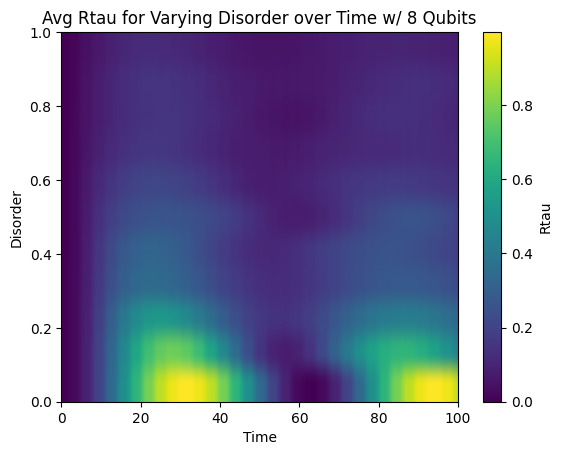

In [5]:
qN = 8
avgRtau_imshow = []
for d in dlist:
    qubit_dR = []
    for _ in range(25):
        qH0, qH1, wm = get_random_qubit_ham(qN, detuning=d, wm=wm)
        qeigvals, qeigstates = qH0.eigenstates()
        qband = qeigvals[-1] - qeigvals[0]

        qargs = {"A": 0.1, "omega": wm}
        qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
        qpsi_t = qt.sesolve(qH, qeigstates[0], tlist)

        # eq 2.3
        temp = []
        H00 = qpsi_t.states[0].dag() * qH0 * qpsi_t.states[0]
        for states in qpsi_t.states:
            H0tau = states.dag() * qH0 * states
            Etau = H0tau - H00
            temp.append(Etau.real)
        temp = np.array(temp)
        qubit_dR.append(temp / qband)
    qubit_dR = np.array(qubit_dR)
    avgRtau_imshow.append(np.mean(qubit_dR, axis=0))

plt.imshow(avgRtau_imshow,
           extent=[tlist.min(), tlist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis')
plt.colorbar(label="Rtau")
plt.title(f"Avg Rtau for Varying Disorder over Time w/ {qN} Qubits")
plt.ylabel("Disorder")
plt.xlabel("Time")
plt.show()